In [134]:
# Data Cleaning and Preprocessing

#This notebook prepares GTFS static and real-time data for analysis.
#It computes arrival delays and generates a cleaned dataset for further visualization and analysis.

In [29]:
!pip install geopandas openpyxl
!pip install gtfs-realtime-bindings

In [32]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from datetime import datetime
import requests
from google.transit import gtfs_realtime_pb2

In [34]:
#Source: https://data.vta.org/datasets/VTA::vta-stops-and-routes-october-2025/explore?layer=1
routes_gdf = gpd.read_file('../02-data/raw/Routes_October_2025.geojson')
routes_gdf = routes_gdf.to_crs("EPSG:2227")

selected_routes = ['22', '522', '23', '523', '25', '60']

#select routes 22, 522, 23, 523, 25, and 60
selected_routes_gdf = routes_gdf[routes_gdf['lineabbr'].isin(selected_routes)]
selected_routes_gdf = selected_routes_gdf.rename(columns={
    'lineid' : 'route_id',
    'lineabbr' : 'route_name',
    'linename' : 'route_desc',
    'SHAPE__Length' : 'route_length',
    'objectid' : 'object_id'
    })

selected_routes_gdf

,route_id,route_name,route_desc,category,route_length,object_id,geometry
2,23875,22,PALO ALTO - EASTRIDGE,Frequent,242559.907697,3,"MULTILINESTRING ((6078119.778 1988262.118, 607..."
3,23876,23,DE ANZA COL - ALUM ROCK STN,Frequent,120202.952188,4,"MULTILINESTRING ((6158969.916 1948773.278, 615..."
4,23879,25,DE ANZA COL - VMC - ALUM ROCK STN,Frequent,140850.289491,5,"MULTILINESTRING ((6159010.362 1938537.341, 615..."
20,23904,60,WINCHESTER STN - MILPITAS BART,Frequent,151256.059019,21,"MULTILINESTRING ((6140271.175 1927485.171, 614..."
54,23896,522,PALO ALTO - EASTRIDGE,Rapid,253522.042435,55,"MULTILINESTRING ((6078119.778 1988262.118, 607..."
55,23897,523,SAN JOSE STATE - LOCKHEED MARTIN,Rapid,162676.690292,56,"MULTILINESTRING ((6117717.98 1975678.638, 6117..."


In [35]:
selected_routes_gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 6 entries, 2 to 55
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   route_id      6 non-null      int32   
 1   route_name    6 non-null      object  
 2   route_desc    6 non-null      object  
 3   category      6 non-null      object  
 4   route_length  6 non-null      float64 
 5   object_id     6 non-null      int32   
 6   geometry      6 non-null      geometry
dtypes: float64(1), geometry(1), int32(2), object(3)
memory usage: 336.0+ bytes


<Axes: >

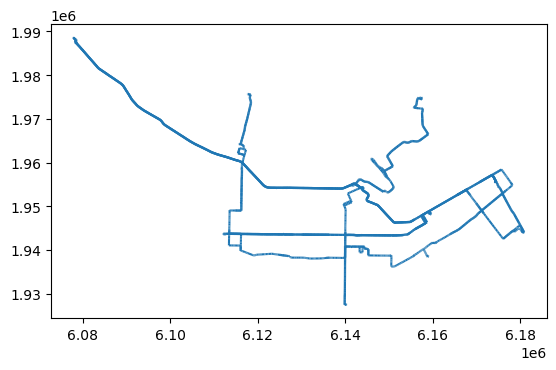

In [36]:
selected_routes_gdf.plot()

In [38]:
#Source: https://data.vta.org/datasets/VTA::vta-stops-and-routes-october-2025/about?layer=0
stations_df = pd.read_csv("../02-data/raw/Bus_LightRail_Stops.csv")
stations_df

,X,Y,routes,linedirid,rtid,stopname,objectid
0,6.144100e+06,1.954226e+06,22,238750,60001,Santa Clara Transit Center,1
1,6.146822e+06,1.959781e+06,"60, 60",239040,60008,San Jose Airport Terminal A,2
2,6.148115e+06,1.958315e+06,60,239041,60011,San Jose Airport Terminal B,3
3,6.150233e+06,1.960219e+06,60,239041,60014,1st & Metro @ Metro Station,4
4,6.141651e+06,1.954992e+06,"22, 59, 60",238750,60020,El Camino & Lafayette,5
...,...,...,...,...,...,...,...
3245,6.140506e+06,1.930527e+06,26,238821,66063,Civic Center & 3rd,3246
3246,6.157411e+06,1.941970e+06,201,238710,66066,Virginia & Virginia Station,3247
3247,6.146206e+06,1.935440e+06,202,238720,66067,Stokes & Southwest Expressway,3248
3248,6.190774e+06,1.935478e+06,"31, 39",238870,66068,San Felipe & Bowery,3249


In [40]:
#Source: https://data.vta.org/pages/f2ebbac0b3a84c5e958ca45a4676f282
ridership_df = pd.read_excel("../02-data/raw/October_2025_Ridership_by_Stop.xlsx")
ridership_df = ridership_df.rename(columns={"Stop_ID_Num": "rtid"})
ridership_df

,rtid,SERVICE_PERIOD,MAIN_CROSS_STREET,ROUTES_SERVED,AVG_BOARDINGS,AVG_ALIGHTINGS,AVG_ACTIVITY
0,60001,Weekday,SANTA CLARA TRANSIT CENTER,22,152.880022,110.852250,263.732272
1,60008,Weekday,SAN JOSE AIRPORT - TERMINAL A,60,106.410278,97.183657,203.593936
2,60011,Weekday,SAN JOSE AIRPORT - TERMINAL B,60,101.895229,69.917892,171.813122
3,60014,Weekday,1ST + METRO,60,99.060686,57.995466,157.056152
4,60020,Weekday,EL CAMINO + LAFAYETTE,"22, 59, 60",40.890986,57.438087,98.329073
...,...,...,...,...,...,...,...
3113,66063,Weekday,CIVIC CENTER + 3RD,26,3.281537,14.682573,17.964110
3114,66066,Weekday,VIRGINIA + VIRGINIA STATION,201,0.333333,0.000000,0.333333
3115,66067,Weekday,STOKES + SOUTHWEST EXPWY,202,0.000000,0.357143,0.357143
3116,66068,Weekday,SAN FELIPE + BOWERY,"31, 39",1.279642,0.336508,1.616150


In [41]:
station_ridership_df = pd.merge(stations_df, ridership_df, on='rtid', how='left')
station_ridership_df

,X,Y,routes,linedirid,rtid,stopname,objectid,SERVICE_PERIOD,MAIN_CROSS_STREET,ROUTES_SERVED,AVG_BOARDINGS,AVG_ALIGHTINGS,AVG_ACTIVITY
0,6.144100e+06,1.954226e+06,22,238750,60001,Santa Clara Transit Center,1,Weekday,SANTA CLARA TRANSIT CENTER,22,152.880022,110.852250,263.732272
1,6.146822e+06,1.959781e+06,"60, 60",239040,60008,San Jose Airport Terminal A,2,Weekday,SAN JOSE AIRPORT - TERMINAL A,60,106.410278,97.183657,203.593936
2,6.148115e+06,1.958315e+06,60,239041,60011,San Jose Airport Terminal B,3,Weekday,SAN JOSE AIRPORT - TERMINAL B,60,101.895229,69.917892,171.813122
3,6.150233e+06,1.960219e+06,60,239041,60014,1st & Metro @ Metro Station,4,Weekday,1ST + METRO,60,99.060686,57.995466,157.056152
4,6.141651e+06,1.954992e+06,"22, 59, 60",238750,60020,El Camino & Lafayette,5,Weekday,EL CAMINO + LAFAYETTE,"22, 59, 60",40.890986,57.438087,98.329073
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3245,6.140506e+06,1.930527e+06,26,238821,66063,Civic Center & 3rd,3246,Weekday,CIVIC CENTER + 3RD,26,3.281537,14.682573,17.964110
3246,6.157411e+06,1.941970e+06,201,238710,66066,Virginia & Virginia Station,3247,Weekday,VIRGINIA + VIRGINIA STATION,201,0.333333,0.000000,0.333333
3247,6.146206e+06,1.935440e+06,202,238720,66067,Stokes & Southwest Expressway,3248,Weekday,STOKES + SOUTHWEST EXPWY,202,0.000000,0.357143,0.357143
3248,6.190774e+06,1.935478e+06,"31, 39",238870,66068,San Felipe & Bowery,3249,Weekday,SAN FELIPE + BOWERY,"31, 39",1.279642,0.336508,1.616150


In [42]:
#set routes data type to str only and if 2 routes share a station, give each its own row for easier filtering later
station_ridership_df["routes"] = station_ridership_df["routes"].str.split(", ")
station_ridership_df = station_ridership_df.explode("routes")
station_ridership_df = station_ridership_df.drop_duplicates()

station_ridership_gdf_geometry = [Point(xy) for xy in zip(station_ridership_df["X"], station_ridership_df["Y"])]

station_ridership_gdf = gpd.GeoDataFrame(station_ridership_df, geometry=station_ridership_gdf_geometry, crs="EPSG:2227")
station_ridership_gdf

,X,Y,routes,linedirid,rtid,stopname,objectid,SERVICE_PERIOD,MAIN_CROSS_STREET,ROUTES_SERVED,AVG_BOARDINGS,AVG_ALIGHTINGS,AVG_ACTIVITY,geometry
0,6.144100e+06,1.954226e+06,22,238750,60001,Santa Clara Transit Center,1,Weekday,SANTA CLARA TRANSIT CENTER,22,152.880022,110.852250,263.732272,POINT (6144099.628 1954225.52)
1,6.146822e+06,1.959781e+06,60,239040,60008,San Jose Airport Terminal A,2,Weekday,SAN JOSE AIRPORT - TERMINAL A,60,106.410278,97.183657,203.593936,POINT (6146822.451 1959780.783)
2,6.148115e+06,1.958315e+06,60,239041,60011,San Jose Airport Terminal B,3,Weekday,SAN JOSE AIRPORT - TERMINAL B,60,101.895229,69.917892,171.813122,POINT (6148114.706 1958314.711)
3,6.150233e+06,1.960219e+06,60,239041,60014,1st & Metro @ Metro Station,4,Weekday,1ST + METRO,60,99.060686,57.995466,157.056152,POINT (6150233.012 1960218.742)
4,6.141651e+06,1.954992e+06,22,238750,60020,El Camino & Lafayette,5,Weekday,EL CAMINO + LAFAYETTE,"22, 59, 60",40.890986,57.438087,98.329073,POINT (6141651.003 1954992.246)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3246,6.157411e+06,1.941970e+06,201,238710,66066,Virginia & Virginia Station,3247,Weekday,VIRGINIA + VIRGINIA STATION,201,0.333333,0.000000,0.333333,POINT (6157411.327 1941969.795)
3247,6.146206e+06,1.935440e+06,202,238720,66067,Stokes & Southwest Expressway,3248,Weekday,STOKES + SOUTHWEST EXPWY,202,0.000000,0.357143,0.357143,POINT (6146206.479 1935440.473)
3248,6.190774e+06,1.935478e+06,31,238870,66068,San Felipe & Bowery,3249,Weekday,SAN FELIPE + BOWERY,"31, 39",1.279642,0.336508,1.616150,POINT (6190773.704 1935477.602)
3248,6.190774e+06,1.935478e+06,39,238870,66068,San Felipe & Bowery,3249,Weekday,SAN FELIPE + BOWERY,"31, 39",1.279642,0.336508,1.616150,POINT (6190773.704 1935477.602)


In [43]:
#remove unnecessary columns
cols = [
    "routes",
    "linedirid",
    "rtid", 
    "stopname", 
    "AVG_BOARDINGS", 
    "AVG_ALIGHTINGS",
    "AVG_ACTIVITY",
    "geometry"
]

ridership_gdf = station_ridership_gdf[cols].copy()

ridership_gdf = ridership_gdf.rename(columns={
    "routes": "route_name",
    "linedirid": "route_direction_id",
    "rtid": "stop_id",
    "stopname": "stop_name",
    "AVG_BOARDINGS": "boardings",
    "AVG_ALIGHTINGS": "alightings",
    "AVG_ACTIVITY": "total_b_a"
})

ridership_gdf

,route_name,route_direction_id,stop_id,stop_name,boardings,alightings,total_b_a,geometry
0,22,238750,60001,Santa Clara Transit Center,152.880022,110.852250,263.732272,POINT (6144099.628 1954225.52)
1,60,239040,60008,San Jose Airport Terminal A,106.410278,97.183657,203.593936,POINT (6146822.451 1959780.783)
2,60,239041,60011,San Jose Airport Terminal B,101.895229,69.917892,171.813122,POINT (6148114.706 1958314.711)
3,60,239041,60014,1st & Metro @ Metro Station,99.060686,57.995466,157.056152,POINT (6150233.012 1960218.742)
4,22,238750,60020,El Camino & Lafayette,40.890986,57.438087,98.329073,POINT (6141651.003 1954992.246)
...,...,...,...,...,...,...,...,...
3246,201,238710,66066,Virginia & Virginia Station,0.333333,0.000000,0.333333,POINT (6157411.327 1941969.795)
3247,202,238720,66067,Stokes & Southwest Expressway,0.000000,0.357143,0.357143,POINT (6146206.479 1935440.473)
3248,31,238870,66068,San Felipe & Bowery,1.279642,0.336508,1.616150,POINT (6190773.704 1935477.602)
3248,39,238870,66068,San Felipe & Bowery,1.279642,0.336508,1.616150,POINT (6190773.704 1935477.602)


In [44]:
#select routes 22, 522, 23, 523, 25, and 60
selected_ridership_gdf = ridership_gdf[ridership_gdf['route_name'].isin(selected_routes)]
selected_ridership_gdf

,route_name,route_direction_id,stop_id,stop_name,boardings,alightings,total_b_a,geometry
0,22,238750,60001,Santa Clara Transit Center,152.880022,110.852250,263.732272,POINT (6144099.628 1954225.52)
1,60,239040,60008,San Jose Airport Terminal A,106.410278,97.183657,203.593936,POINT (6146822.451 1959780.783)
2,60,239041,60011,San Jose Airport Terminal B,101.895229,69.917892,171.813122,POINT (6148114.706 1958314.711)
3,60,239041,60014,1st & Metro @ Metro Station,99.060686,57.995466,157.056152,POINT (6150233.012 1960218.742)
4,22,238750,60020,El Camino & Lafayette,40.890986,57.438087,98.329073,POINT (6141651.003 1954992.246)
...,...,...,...,...,...,...,...,...
3219,23,238761,66001,San Carlos & Meridian,156.296391,174.049290,330.345680,POINT (6150710.015 1943405.861)
3219,523,238761,66001,San Carlos & Meridian,156.296391,174.049290,330.345680,POINT (6150710.015 1943405.861)
3221,60,239040,66019,San Jose Airport Terminal B,105.515644,69.771954,175.287597,POINT (6148161.172 1958273.948)
3225,25,238790,66033,Clove & Ginger,37.628251,52.159478,89.787729,POINT (6143691.14 1939440.166)


<Axes: >

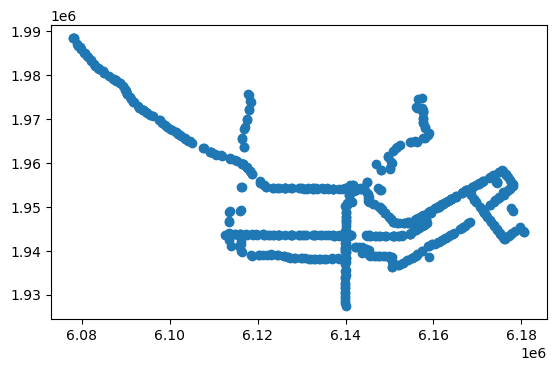

In [45]:
selected_ridership_gdf.plot()

In [47]:
#save in separate folder
selected_routes_gdf.to_csv('../02-data/processed/selected_routes.csv')
selected_ridership_gdf.to_csv('../02-data/processed/selected_station_ridership.csv')

In [48]:
#Source: https://gisdata-csj.opendata.arcgis.com/datasets/CSJ::average-daily-traffic/explore?location=37.332044%2C-121.880204%2C10
adt_df = pd.read_csv('../02-data/raw/Average_Daily_Traffic.csv')
adt_gdf_geometry = [Point(xy) for xy in zip(adt_df["X"], adt_df["Y"])]

adt_gdf = gpd.GeoDataFrame(adt_df, geometry=adt_gdf_geometry, crs="EPSG:2227")
adt_gdf = adt_gdf.to_crs("EPSG:2227")
adt_gdf

,X,Y,OBJECTID,FACILITYID,INTID,LATITUDE,LONGITUDE,COUNTDATE,ADT,STREETONE,...,STREETTWO,TRAVELDIRE,NEARINTERS,CITY,ADTONE,ADTTWO,CREATIONDATE,LASTUPDATE,NOTES,geometry
0,6.159659e+06,1.952402e+06,4446,2045,2045,37.348694,-121.883045,2018/03/27 00:00:00+00,5613.0,13TH ST,...,WASHINGTON ST,N/S,13TH ST & WASHINGTON ST,San Jose,2339.0,3274.0,NaN,2021/03/18 17:05:47+00,,POINT (6159659.425 1952401.843)
1,6.165294e+06,1.938841e+06,4447,2046,2046,37.311681,-121.862988,2018/04/10 00:00:00+00,6265.0,7TH ST,...,LEO AVE,N/S,7TH ST & LEO AVE,San Jose,2842.0,3423.0,NaN,2021/03/18 17:05:47+00,,POINT (6165293.598 1938841.482)
2,6.158495e+06,1.951732e+06,4448,2047,2047,37.346808,-121.887016,2018/07/31 00:00:00+00,1043.0,9TH ST,...,WASHINGTON ST,N/S,9TH ST & WASHINGTON ST,San Jose,589.0,454.0,NaN,2021/03/18 17:05:47+00,,POINT (6158494.955 1951732.473)
3,6.158545e+06,1.951646e+06,4449,2048,2048,37.346572,-121.886841,2018/07/31 00:00:00+00,1207.0,9TH ST,...,WASHINGTON ST,N/S,9TH ST & WASHINGTON ST,San Jose,740.0,467.0,NaN,2021/03/18 17:05:47+00,,POINT (6158544.746 1951645.735)
4,6.148940e+06,1.958002e+06,4450,2049,2049,37.363632,-121.920211,2018/08/22 00:00:00+00,14432.0,AIRPORT BLVD,...,SKYPORT DR,One Way,AIRPORT BLVD & SKYPORT DR,San Jose,NaN,NaN,NaN,2021/03/18 17:05:47+00,,POINT (6148939.759 1958001.956)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2394,6.169466e+06,1.956389e+06,7281,4473,4473,37.360029,-121.849505,2021/12/02 00:00:00+00,3994.0,Jose Figueres Ave,...,Rio Guacimal Ct,N/S,Jose Figueres Ave & Rio Guacimal Ct,San Jose,1983.0,2011.0,NaN,2022/04/14 20:14:37+00,NaN,POINT (6169465.578 1956389.19)
2395,6.171081e+06,1.954917e+06,7282,4474,4474,37.356051,-121.843873,2021/12/02 00:00:00+00,1207.0,Scharff Ave,...,Lausett Ave,N/S,Scharff Ave & Lausett Ave,San Jose,656.0,551.0,NaN,2022/04/14 20:14:37+00,NaN,POINT (6171081.379 1954917.494)
2396,6.164263e+06,1.950131e+06,7283,4475,4475,37.342634,-121.867090,2021/12/02 00:00:00+00,3068.0,San Antonio St,...,21st St,E/W,San Antonio St & 21st St,San Jose,1521.0,1547.0,NaN,2022/04/14 20:14:37+00,NaN,POINT (6164262.808 1950130.677)
2397,6.164839e+06,1.950568e+06,7284,4476,4476,37.343858,-121.865132,2021/12/02 00:00:00+00,4238.0,San Antonio St,...,23rd St,E/W,San Antonio St & 23rd St,San Jose,2305.0,1933.0,NaN,2022/04/14 20:14:37+00,NaN,POINT (6164838.516 1950567.683)


In [49]:
cols = [
    "OBJECTID",
    "ADT",
    "STREETONE", 
    "DIRECTION", 
    "STREETTWO", 
    "NEARINTERS",
    "geometry"
]

sj_adt_gdf = adt_gdf[cols].copy()

sj_adt_gdf = sj_adt_gdf.rename(columns={
    "OBJECTID" : "counter_id",
    "ADT" : "adt",
    "STREETONE" : "main_road", 
    "DIRECTION" : "counter_location", 
    "STREETTWO" : "cross_road", 
    "NEARINTERS" : "nearby_intersect"
})

sj_adt_gdf.dropna()
sj_adt_gdf['main_road'] = [item.upper() for item in sj_adt_gdf['main_road']]
sj_adt_gdf['cross_road'] = [item.upper() for item in sj_adt_gdf['cross_road']]
sj_adt_gdf['nearby_intersect'] = [item.upper() for item in sj_adt_gdf['nearby_intersect']]
sj_adt_gdf

,counter_id,adt,main_road,counter_location,cross_road,nearby_intersect,geometry
0,4446,5613.0,13TH ST,N of,WASHINGTON ST,13TH ST & WASHINGTON ST,POINT (6159659.425 1952401.843)
1,4447,6265.0,7TH ST,S of,LEO AVE,7TH ST & LEO AVE,POINT (6165293.598 1938841.482)
2,4448,1043.0,9TH ST,N of,WASHINGTON ST,9TH ST & WASHINGTON ST,POINT (6158494.955 1951732.473)
3,4449,1207.0,9TH ST,S of,WASHINGTON ST,9TH ST & WASHINGTON ST,POINT (6158544.746 1951645.735)
4,4450,14432.0,AIRPORT BLVD,S of,SKYPORT DR,AIRPORT BLVD & SKYPORT DR,POINT (6148939.759 1958001.956)
...,...,...,...,...,...,...,...
2394,7281,3994.0,JOSE FIGUERES AVE,S of,RIO GUACIMAL CT,JOSE FIGUERES AVE & RIO GUACIMAL CT,POINT (6169465.578 1956389.19)
2395,7282,1207.0,SCHARFF AVE,N of,LAUSETT AVE,SCHARFF AVE & LAUSETT AVE,POINT (6171081.379 1954917.494)
2396,7283,3068.0,SAN ANTONIO ST,E of,21ST ST,SAN ANTONIO ST & 21ST ST,POINT (6164262.808 1950130.677)
2397,7284,4238.0,SAN ANTONIO ST,E of,23RD ST,SAN ANTONIO ST & 23RD ST,POINT (6164838.516 1950567.683)


In [50]:
#create a buffer around the selected routes, then select all traffic counters within the buffer
route_buffers = selected_routes_gdf.copy()
route_buffers['geometry'] = route_buffers['geometry'].buffer(250)
route_buffers

,route_id,route_name,route_desc,category,route_length,object_id,geometry
2,23875,22,PALO ALTO - EASTRIDGE,Frequent,242559.907697,3,"POLYGON ((6077534.618 1988551.218, 6077534.591..."
3,23876,23,DE ANZA COL - ALUM ROCK STN,Frequent,120202.952188,4,"POLYGON ((6111857.309 1943710.691, 6111857.38 ..."
4,23879,25,DE ANZA COL - VMC - ALUM ROCK STN,Frequent,140850.289491,5,"POLYGON ((6113146.198 1941141.056, 6113146.078..."
20,23904,60,WINCHESTER STN - MILPITAS BART,Frequent,151256.059019,21,"POLYGON ((6139345.747 1950518.707, 6139345.608..."
54,23896,522,PALO ALTO - EASTRIDGE,Rapid,253522.042435,55,"POLYGON ((6077534.618 1988551.218, 6077534.591..."
55,23897,523,SAN JOSE STATE - LOCKHEED MARTIN,Rapid,162676.690292,56,"POLYGON ((6113181.487 1943682.679, 6113181.4 1..."


In [51]:
selected_sj_adt = gpd.sjoin(sj_adt_gdf, route_buffers, how="inner", predicate="within")
selected_sj_adt

,counter_id,adt,main_road,counter_location,cross_road,nearby_intersect,geometry,index_right,route_id,route_name,route_desc,category,route_length,object_id
4,4450,14432.0,AIRPORT BLVD,S of,SKYPORT DR,AIRPORT BLVD & SKYPORT DR,POINT (6148939.759 1958001.956),20,23904,60,WINCHESTER STN - MILPITAS BART,Frequent,151256.059019,21
11,4457,8385.0,ALMADEN AVE,N of,WILLOW ST,ALMADEN AVE & WILLOW ST,POINT (6159716.967 1941603.893),4,23879,25,DE ANZA COL - VMC - ALUM ROCK STN,Frequent,140850.289491,5
23,4469,848.0,BLEWETT AVE,S of,WILLOW ST,BLEWETT AVE & WILLOW ST,POINT (6154536.488 1937960.998),4,23879,25,DE ANZA COL - VMC - ALUM ROCK STN,Frequent,140850.289491,5
24,4470,936.0,BLEWETTE AVE,S of,WILLOW ST,BLEWETTE AVE & WILLOW ST,POINT (6154536.488 1937960.998),4,23879,25,DE ANZA COL - VMC - ALUM ROCK STN,Frequent,140850.289491,5
28,4474,45690.0,BROKAW RD,E of,OAKLAND RD,BROKAW RD&OAKLAND RD,POINT (6156171.62 1964851.784),20,23904,60,WINCHESTER STN - MILPITAS BART,Frequent,151256.059019,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2364,7251,13221.0,KING RD,S of,OCALA AVE,KING RD & OCALA AVE,POINT (6173723.992 1945717.512),2,23875,22,PALO ALTO - EASTRIDGE,Frequent,242559.907697,3
2374,7261,18169.0,STORY RD,E of,BAL HARBOR WAY,STORY RD & BAL HARBOR WAY,POINT (6172131.01 1949785.076),4,23879,25,DE ANZA COL - VMC - ALUM ROCK STN,Frequent,140850.289491,5
2375,7262,20206.0,STORY RD,E of,JACKSON AVE,STORY RD & JACKSON AVE,POINT (6174397.292 1951653.894),4,23879,25,DE ANZA COL - VMC - ALUM ROCK STN,Frequent,140850.289491,5
2376,7263,21056.0,STORY RD,W of,ROBERTS AVE,STORY RD & ROBERTS AVE,POINT (6166346.746 1945014.702),4,23879,25,DE ANZA COL - VMC - ALUM ROCK STN,Frequent,140850.289491,5


<Axes: >

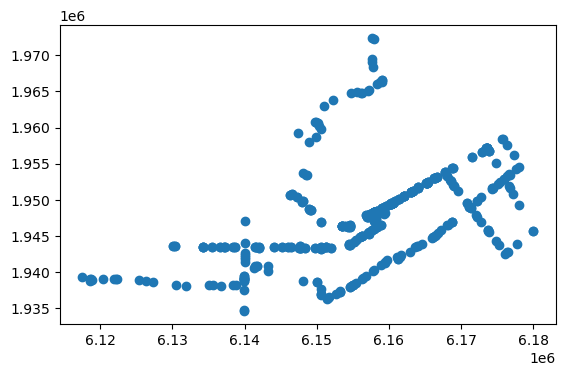

In [52]:
selected_sj_adt.plot()

In [53]:
#average daily traffic for streets in San Jose that the selected bus routes run along
selected_sj_adt.to_csv("../02-data/processed/selected_sj_adt.csv")

In [55]:
# --- Vehicle positions: buffer filter to corridor (routes 22/522/23/523/25/60) ---

VEHICLE_CSV = "../02-data/processed/vehicle_route_location_speed_data_20260326_103149.csv"
OUT_CSV = "../02-data/processed/vehicle_points_filtered_buffer250ft.csv"
BUFFER_FT = 250  # EPSG:2227 feet (~76m)

# ensure routes are in EPSG:2227 (feet)
if selected_routes_gdf.crs is None or selected_routes_gdf.crs.to_string() != "EPSG:2227":
    selected_routes_gdf = selected_routes_gdf.to_crs("EPSG:2227")

# route corridor buffer
route_buffers = selected_routes_gdf.copy()
route_buffers["geometry"] = route_buffers.geometry.buffer(BUFFER_FT)

# load vehicle csv
veh = pd.read_csv(VEHICLE_CSV)
veh = veh.dropna(subset=["lat", "lon", "route_id", "time"])
veh["route_id"] = veh["route_id"].astype(str).str.strip()

veh_gdf = gpd.GeoDataFrame(
    veh,
    geometry=gpd.points_from_xy(veh["lon"], veh["lat"]),
    crs="EPSG:4326"
).to_crs("EPSG:2227")

veh_in = gpd.sjoin(
    veh_gdf,
    route_buffers[["route_name", "geometry"]],
    how="inner",
    predicate="within"
)

veh_in = veh_in.drop_duplicates(subset=["bus_id", "trip_id", "time", "route_id"])


print("veh_gdf rows:", len(veh_gdf))
print("veh_in rows :", len(veh_in))
print("kept %:", round(len(veh_in) / len(veh_gdf), 3))

veh_gdf rows: 82115
veh_in rows : 80834
kept %: 0.984


In [56]:
# --- Summary stats for midterm (counts before/after by route_id) ---
before_counts = veh_gdf.groupby("route_id").size().rename("before_n").reset_index()
after_counts  = veh_in.groupby("route_id").size().rename("after_n").reset_index()

counts = before_counts.merge(after_counts, on="route_id", how="left").fillna({"after_n": 0})
counts["after_n"] = counts["after_n"].astype(int)
counts["kept_pct"] = (counts["after_n"] / counts["before_n"]).round(3)

display(counts.sort_values("route_id"))

# save filtered output
veh_in_out = veh_in.drop(columns=[c for c in ["index_right"] if c in veh_in.columns])
veh_in_out.to_csv(OUT_CSV, index=False)
print("Saved:", OUT_CSV)

,route_id,before_n,after_n,kept_pct
0,22,19313,18946,0.981
1,23,11749,11504,0.979
2,25,14307,14140,0.988
3,60,12318,12163,0.987
4,Rapid 522,15920,15707,0.987
5,Rapid 523,8508,8374,0.984


Saved: ../02-data/processed/vehicle_points_filtered_buffer250ft.csv


In [114]:
# Load GTFS static data
routes = pd.read_csv("../02-data/raw/Static_routes.txt")
trips = pd.read_csv("../02-data/raw/Static_trips.txt")
stop_times = pd.read_csv("../02-data/raw/Static_stop_times.txt")
stops = pd.read_csv("../02-data/raw/Static_stops.txt")

# Load GTFS-Realtime TripUpdates
tripupdates = pd.read_csv("../02-data/raw/tripupdates_20260326.csv")

In [122]:
# Ensure consistent data types
tripupdates["trip_id"] = tripupdates["trip_id"].astype(str)
stop_times["trip_id"] = stop_times["trip_id"].astype(str)
trips["trip_id"] = trips["trip_id"].astype(str)

tripupdates["stop_id"] = tripupdates["stop_id"].astype(str)
stop_times["stop_id"] = stop_times["stop_id"].astype(str)
stops["stop_id"] = stops["stop_id"].astype(str)

tripupdates["stop_sequence"] = tripupdates["stop_sequence"].astype(int)
stop_times["stop_sequence"] = stop_times["stop_sequence"].astype(int)

In [123]:
# Merge realtime and scheduled data
merged = tripupdates.merge(
    stop_times[["trip_id", "stop_sequence", "arrival_time"]],
    on=["trip_id", "stop_sequence"],
    how="left"
)

In [124]:
# Convert scheduled arrival time to seconds
def time_to_seconds(t):
    if pd.isna(t):
        return None
    h, m, s = map(int, t.split(":"))
    return h * 3600 + m * 60 + s

merged["scheduled_arrival_sec"] = merged["arrival_time"].apply(time_to_seconds)

In [125]:
# Convert actual arrival time to local time
merged["actual_arrival_time"] = pd.to_datetime(
    merged["arr_time"], unit="s", utc=True
).dt.tz_convert("America/Los_Angeles")

merged["actual_arrival_sec"] = (
    merged["actual_arrival_time"].dt.hour * 3600 +
    merged["actual_arrival_time"].dt.minute * 60 +
    merged["actual_arrival_time"].dt.second
)

In [126]:
# Compute delay
merged["computed_delay_sec"] = (
    merged["actual_arrival_sec"] - merged["scheduled_arrival_sec"]
)

In [127]:
# Adjust for trips crossing midnight
merged.loc[merged["computed_delay_sec"] < -12 * 3600, "computed_delay_sec"] += 24 * 3600

In [128]:
# Merge route and stop information
merged = merged.merge(trips[["trip_id", "route_id"]], on="trip_id", how="left")
merged = merged.merge(stops[["stop_id", "stop_name"]], on="stop_id", how="left")

In [129]:
# Remove invalid records
cleaned_data = merged.dropna(subset=["computed_delay_sec"])

In [132]:
cleaned_data["computed_delay_sec"].describe()

count    3281.000000
mean      -53.654678
std       176.821861
min      -921.000000
25%      -125.000000
50%       -63.000000
75%        -6.000000
max      1030.000000
Name: computed_delay_sec, dtype: float64

In [130]:
# Save cleaned dataset
cleaned_data.to_csv("../02-data/processed/cleaned_delay_data.csv", index=False)

print("Cleaned data saved to data/processed/cleaned_delay_data.csv")

Cleaned data saved to data/processed/cleaned_delay_data.csv
